In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
# Maxwell-Boltzmann function for fitting histograms
def MB(v:np.array, temp:float,C:float):
    return C*(1/( (2*np.pi*temp)**(1.5)) )*4*np.pi*(v**2)*np.exp(-(v**2)/(2*temp))

# Exercise 04.1: Maxwell-Boltzmann distribution


The Maxwell-Boltzmann distribution using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

<span style="color:red">Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.</span>

## Implementation

### Measure of POFV

Set Maximum velocity at $4\sqrt{T^*}$ so that the histogram will consider the 99.8866% of the Maxwell-Boltzmann distribution. Then create a vector of `_n_bins` of width `_bin_size_v=4*sqrt(_temp)/_npart`. 

For every particle compute the norm of velocity and increment the corresponding bin at position `k=floor(norm(_particle(i).get_velocity())/_bin_size_v)`


```c++

vec vel_hist(_n_bins_v);
vel_hist.zeros();
    [....]
for(int i=0; i<_npart; i++)
{
  // bin k = [k*_bin_size_v, (k+1)*_bin_size_v]      
  int k=floor(norm(_particle(i).getvelocity())/_bin_size_v);
  //ignore velocities greater than the maximum
  if(k<_n_bins_v) vel_hist(k)+=1;
}

//save measure on consecutives indexes 
for (int k=0; k<_n_bins_v; ++k)
{
    _measurement(_index_pofv+k)=vel_hist(k);
}

```

### Average of POFV
```c++
coutf.open("../OUTPUT/pofv.dat", ios::app);

for(int k=0; k<_n_bins_v; ++k)
{
    average=_average(_index_pofv+k);
    sum_average = _global_av(_index_pofv+k);
    sum_ave2 = _global_av2(_index_pofv+k);

    coutf<<setw(12)<<k*_bin_size_v+_bin_size_v/2.
         <<setw(12)<<average/_npart  
         <<setw(12)<<sum_average/(blk*_npart)
         <<setw(12)<<this->error(sum_average/_npart, sum_ave2/(_npart*_npart), blk)
         <<endl;

```

#### Load data

In [6]:
# POFV data
df_mb=pd.read_csv('OUTPUT/distrib/MB/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_av', 'err'], skiprows=1,
               sep=r"\s+")
df_mb['block']=0
df_mb['block']=df_mb.index//30

# Temperature data
T=pd.read_csv('OUTPUT/distrib/MB/temperature.dat', skiprows=1, delimiter=r'\s+',names=['block','actual_T','T_ave','error'])



#### Fit temperature from POFV

In [17]:
mb_fit={'T_block':[], 'T_ave':[], 'C_block':[], 'C_ave':[]}

for k in df_mb.block.unique():
    # block avg
    temp_ba, c_ba = curve_fit(MB, df_mb.loc[df_mb.block==k]['#vel'], df_mb.loc[df_mb.block==k]['block_avg'] )[0] 
    mb_fit['T_block'].append(temp_ba)
    mb_fit['C_block'].append(c_ba)
    # progressive avg
    temp_pa, c_pa = curve_fit(MB, df_mb.loc[df_mb.block==k]['#vel'], df_mb.loc[df_mb.block==k]['prog_av'] )[0] 
    mb_fit['T_ave'].append(temp_pa)
    mb_fit['C_ave'].append(c_pa)


mb_fit=pd.DataFrame(mb_fit)

#### Plot distribution at different blocks

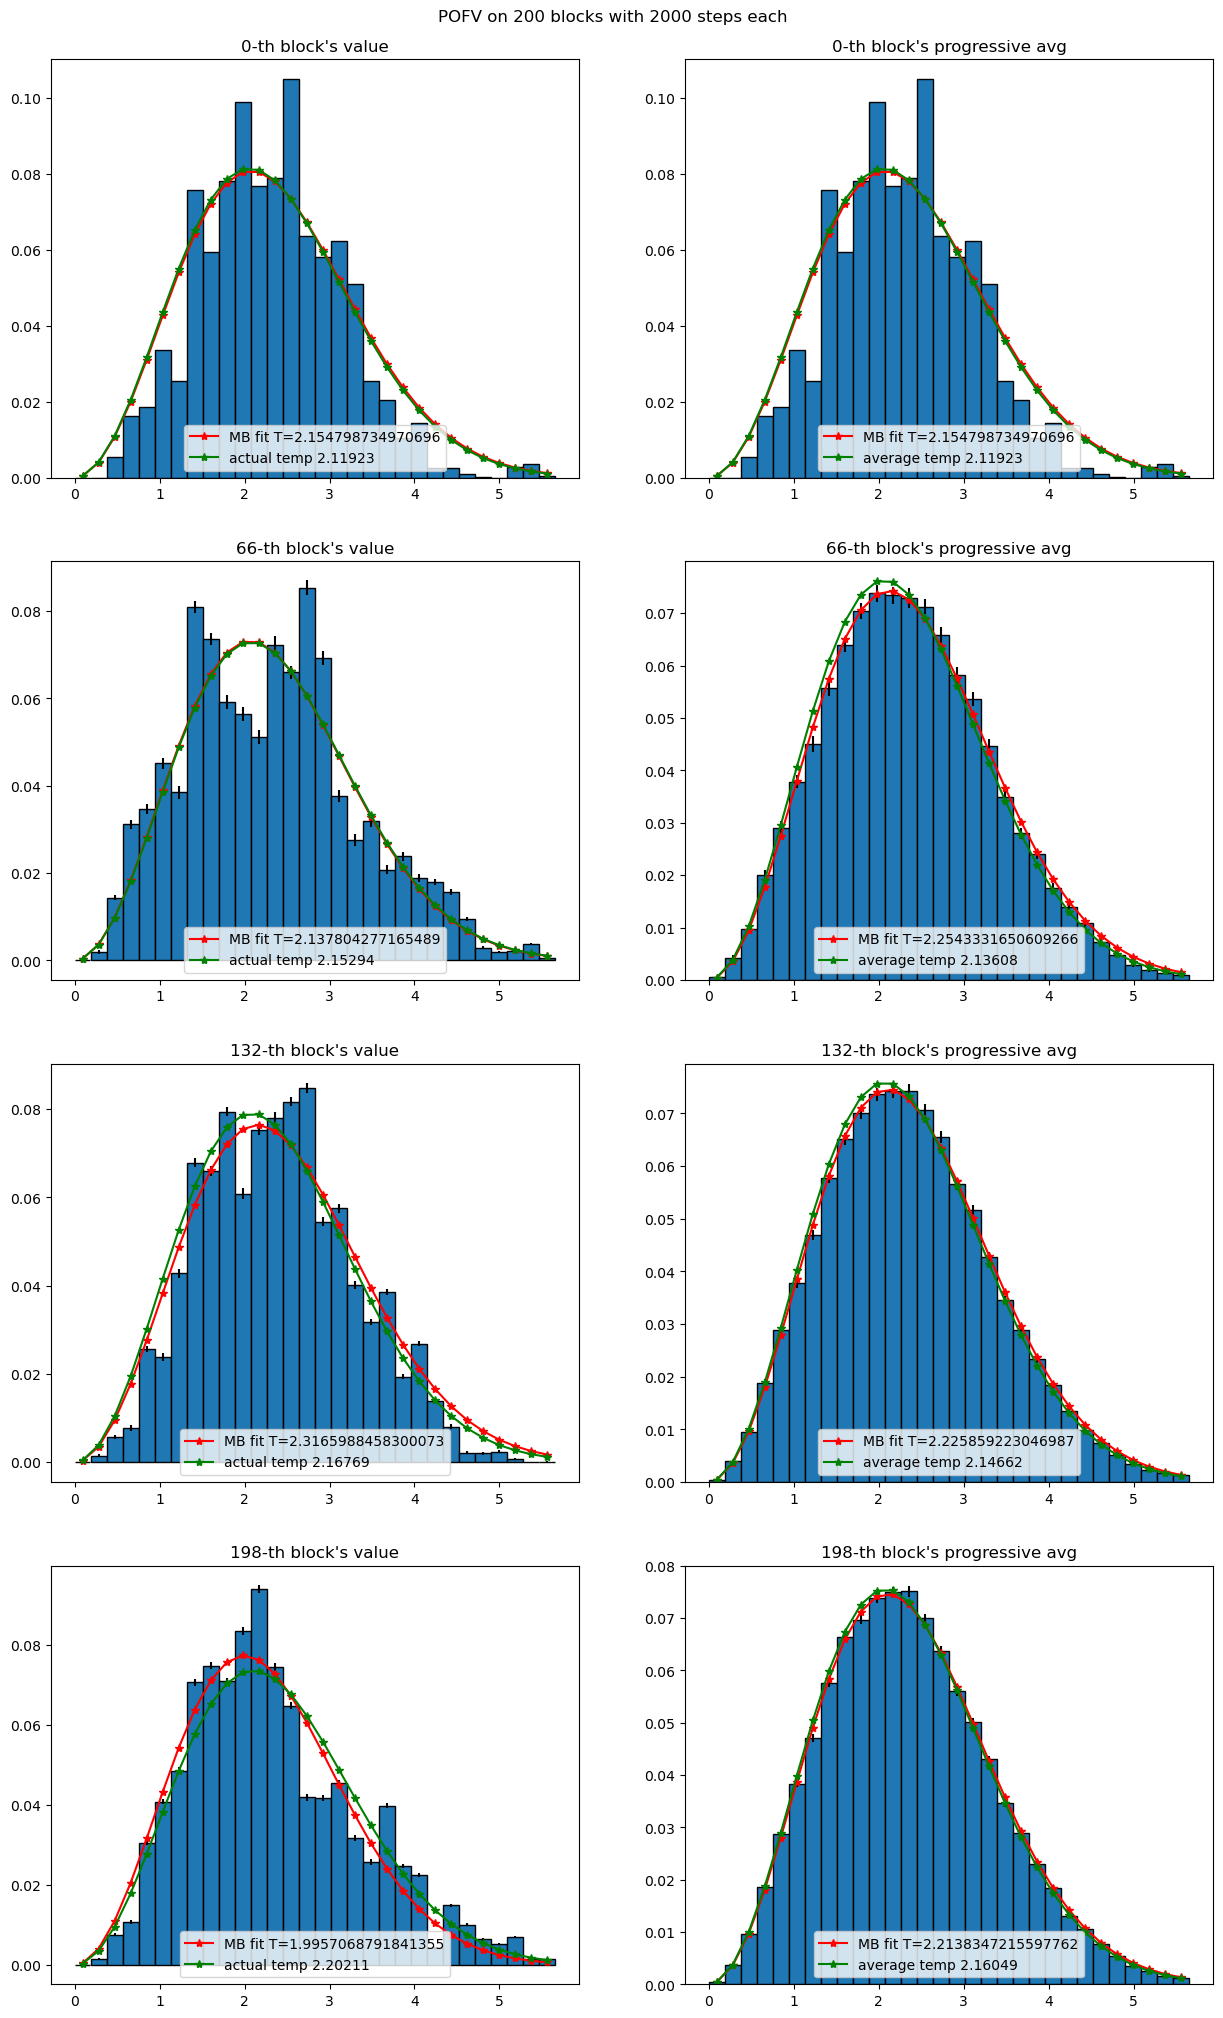

In [58]:
fig, ax=plt.subplots(nrows=4, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 200 blocks with 2000 steps each', y=0.9)

step=df_mb.block.max()//3
for k in range(4):
    #select k block pofv data 
    dfb=df_mb.loc[df_mb['block']==step*k].reset_index(drop=True)

    ax[k,  0].set_title(f'{step*k}-th block\'s value')
    
    # actual data
    ax[k,  0].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    # fit 
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], mb_fit['T_block'][step*k] ,mb_fit['C_block'][step*k])
        , marker='*', c='r', label=f'MB fit T={mb_fit['T_block'][step*k]}')
    
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], T.actual_T[k], mb_fit['C_block'][step*k])
        , marker='*', c='g', label=f'actual temp {T.actual_T[k]}')
    
    ax[k, 0].legend(loc='lower center')

    # prog avg
    ax[k,  1].set_title(f'{step*k}-th block\'s progressive avg')
    # actual data
    ax[k,  1].bar(
        dfb['#vel'], dfb['prog_av'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    # fit 
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], mb_fit['T_ave'][step*k],mb_fit['C_ave'][step*k])
        , marker='*', c='r', label=f'MB fit T={mb_fit['T_ave'][step*k]}')
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], T.T_ave[k], mb_fit['C_ave'][step*k])
        , marker='*', c='g', label=f'average temp {T.T_ave[k]}')
    
    ax[k, 1].legend(loc='lower center')
plt.show()

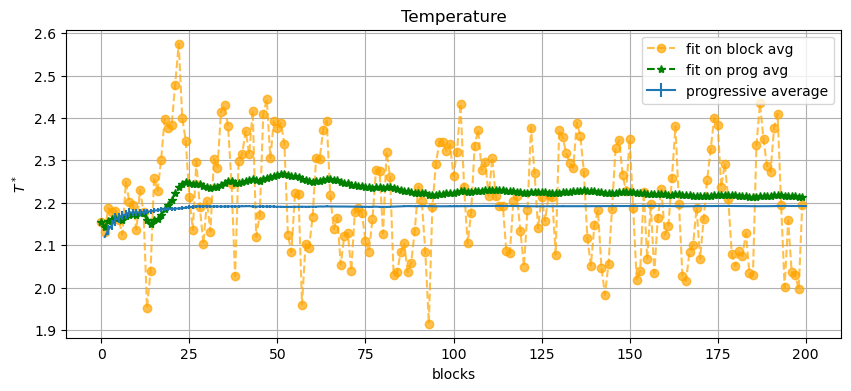

In [60]:
plt.figure(figsize=(10, 4))
plt.title('Temperature')
plt.plot(mb_fit['T_block'],'--o',color='orange', alpha=0.7,  label='fit on block avg')
plt.plot(mb_fit['T_ave'],'--*', color='g', label='fit on prog avg')
plt.errorbar(T.block, T['T_ave'], yerr=T.error,  label='progressive average')
plt.xlabel('blocks')
plt.ylabel(r'$T^*$')
plt.grid()
plt.legend()
plt.show()

### Properties 

In [62]:
K=pd.read_csv('OUTPUT/distrib/MB/kinetic_energy.dat', delimiter=r"\s+")

In [63]:
U=pd.read_csv('OUTPUT/distrib/MB/potential_energy.dat', delimiter=r"\s+")

In [64]:
P=pd.read_csv('OUTPUT/distrib/MB/pressure.dat', delimiter=r"\s+")

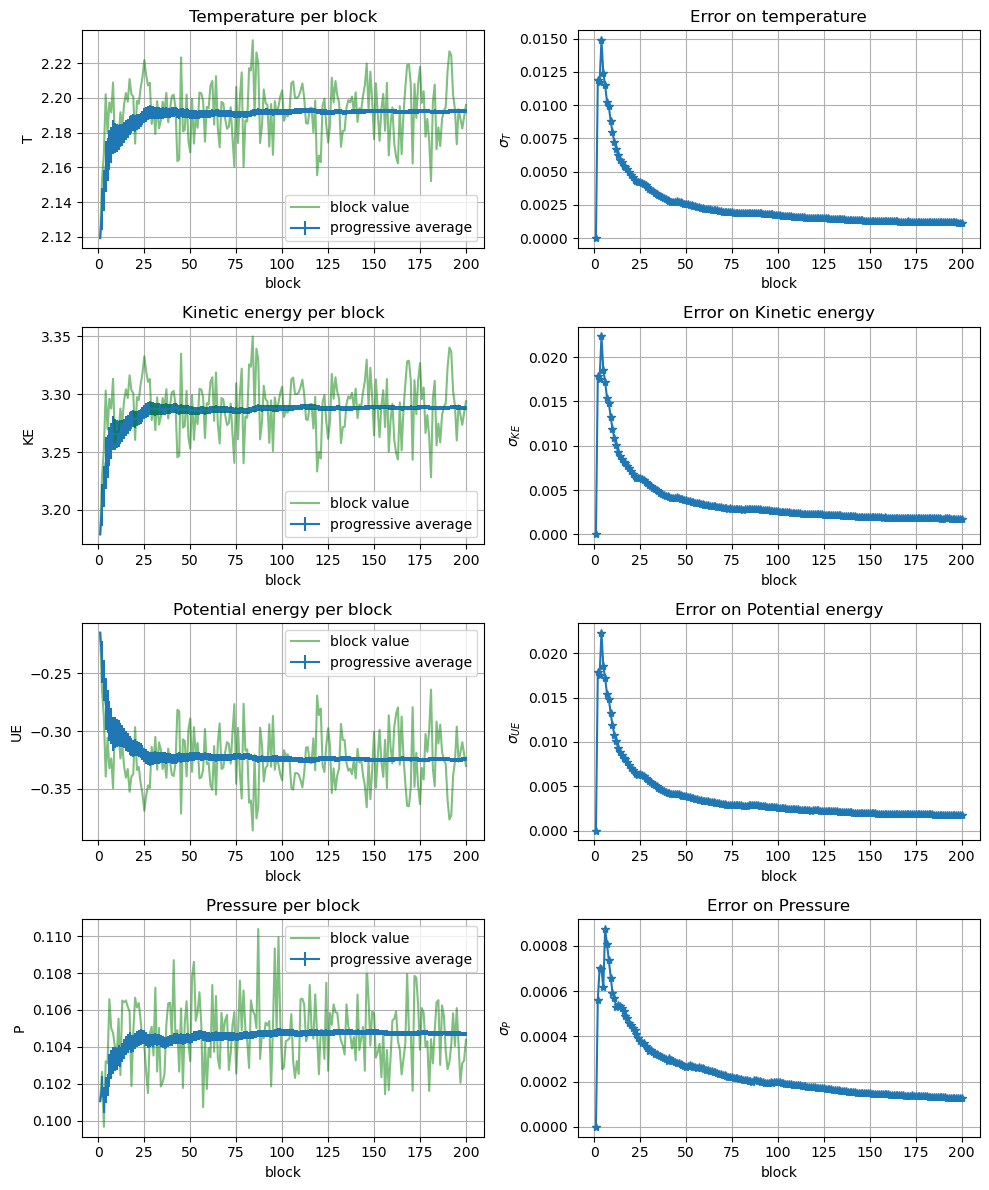

In [66]:
fig, ax = plt.subplots(4,2,  figsize=(10, 12))

ax[0, 0].set_title('Temperature per block')
# block averages
ax[0, 0].plot(T.block, T.actual_T, '-',color='g', alpha=0.5,  label='block value')
# progressive averages
ax[0, 0].errorbar(T.block, T['T_ave'], yerr=T.error,  label='progressive average')
ax[0, 0].set_ylabel('T')

ax[0,1].set_title('Error on temperature')
ax[0,1].plot(T.block, T.error, '-*')
ax[0,1].set_ylabel(r'$\sigma_T$')


ax[1,0].set_title('Kinetic energy per block')
# progressive averages
ax[1,0].errorbar(K['#BLOCK:'], K['KE_AVE:'], yerr=K['ERROR:'], label='progressive average')
# block averages
ax[1,0].plot(K['#BLOCK:'], K['ACTUAL_KE:'], '-',color='g', alpha=0.5,  label='block value')
ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Error on Kinetic energy')
ax[1,1].plot(K['#BLOCK:'], K['ERROR:'], '-*')
ax[1,1].set_ylabel(r'$\sigma_{KE}$')


ax[2,0].set_title('Potential energy per block')
ax[2,0].plot(U['#BLOCK:'], U['ACTUAL_PE:'], ls='-', color='g', alpha=0.5,  label='block value')
ax[2,0].errorbar(U['#BLOCK:'], U['PE_AVE:'], yerr=U['ERROR:'], label='progressive average')
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Error on Potential energy')
ax[2,1].plot(U['#BLOCK:'], U['ERROR:'], '-*')
ax[2,1].set_ylabel(r'$\sigma_{UE}$')


ax[3,0].set_title('Pressure per block')
ax[3,0].plot(P['#BLOCK:'], P['ACTUAL_P:'], ls='-', color='g', alpha=0.5,  label='block value')
ax[3,0].errorbar(P['#BLOCK:'], P['P_AVE:'], yerr=P['ERROR:'], label='progressive average')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Error on Pressure')
ax[3,1].plot(P['#BLOCK:'], P['ERROR:'], '-*')
ax[3,1].set_ylabel(r'$\sigma_{P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')
    ax[k, 0].legend()

fig.tight_layout()

plt.show()

### Histograms Heatmap 

In [223]:
histos=pd.DataFrame(columns=['vel']+[f'block_{k}' for k in range(df_mb['block'].max())])
histos['vel']=df_mb.loc[df_mb['block']==0]['#vel'].values
for k in range(df_mb['block'].max()):
    histos[f'block_{k}']=df_mb.loc[df_mb.block==k]['block_avg'].values 
    


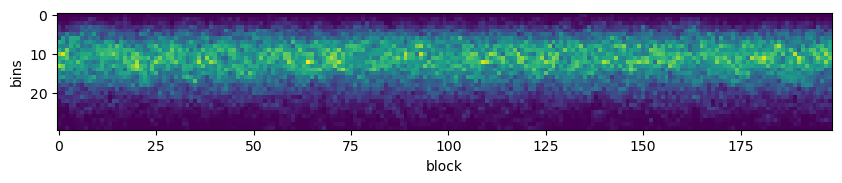

In [122]:
fig,ax = plt.subplots(figsize=(10,10))

ax.imshow(histos[[f'block_{k}' for k in range(len(histos.columns)-1)]])
plt.xlabel('block')
plt.ylabel('bins')
plt.savefig('images/MB_hist.png')
plt.show()

## Esercizio 04.2

mettere i criteri per cui avevo messo blocchi strapiccoli (far vedere l'evoluzione dalla delta
)

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [69]:
df=pd.read_csv('OUTPUT/distrib/delta/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_avg', 'err'], skiprows=1, sep="\s+")

df['block']=0
df['block']=df.index//30
   

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8004/677895036.py:1: SyntaxWarning: invalid escape sequence '\s'
  df=pd.read_csv('OUTPUT/distrib/delta/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_avg', 'err'], skiprows=1, sep="\s+")


In [70]:
T_d=pd.read_csv(
    'OUTPUT/distrib/delta/temperature.dat', delimiter=r"\s+")
T_d

,#BLOCK:,ACTUAL_T:,T_AVE:,ERROR:
0,1,2.00002,2.00002,0.000000
1,2,2.00012,2.00007,0.000036
2,3,2.00032,2.00015,0.000074
3,4,2.00064,2.00027,0.000119
4,5,2.00108,2.00044,0.000173
...,...,...,...,...
19995,19996,2.23006,2.19227,0.000220
19996,19997,2.23220,2.19228,0.000220
19997,19998,2.23856,2.19228,0.000220
19998,19999,2.24900,2.19228,0.000220


In [10]:
# block averages
fit_temp_ba = []
fit_C_ba    = []

# prog avg
fit_temp_pa = []
fit_C_pa    = []


for k in df.block.unique():
    temp_ba, c_ba = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['block_avg'] )[0] 
    fit_temp_ba.append(temp_ba)
    fit_C_ba.append(c_ba)

    temp_pa, c_pa = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['prog_avg'] )[0] 
    fit_temp_pa.append(temp_pa)
    fit_C_pa.append(c_pa)


In [72]:
delta_fit={'T_block':[], 'T_ave':[], 'C_block':[], 'C_ave':[]}

for k in df.block.unique():
    # block avg
    temp_ba, c_ba = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['block_avg'] )[0] 
    delta_fit['T_block'].append(temp_ba)
    delta_fit['C_block'].append(c_ba)
    # progressive avg
    temp_pa, c_pa = curve_fit(MB, df.loc[df.block==k]['#vel'], df.loc[df.block==k]['prog_avg'] )[0] 
    delta_fit['T_ave'].append(temp_pa)
    delta_fit['C_ave'].append(c_pa)


delta_fit=pd.DataFrame(delta_fit)

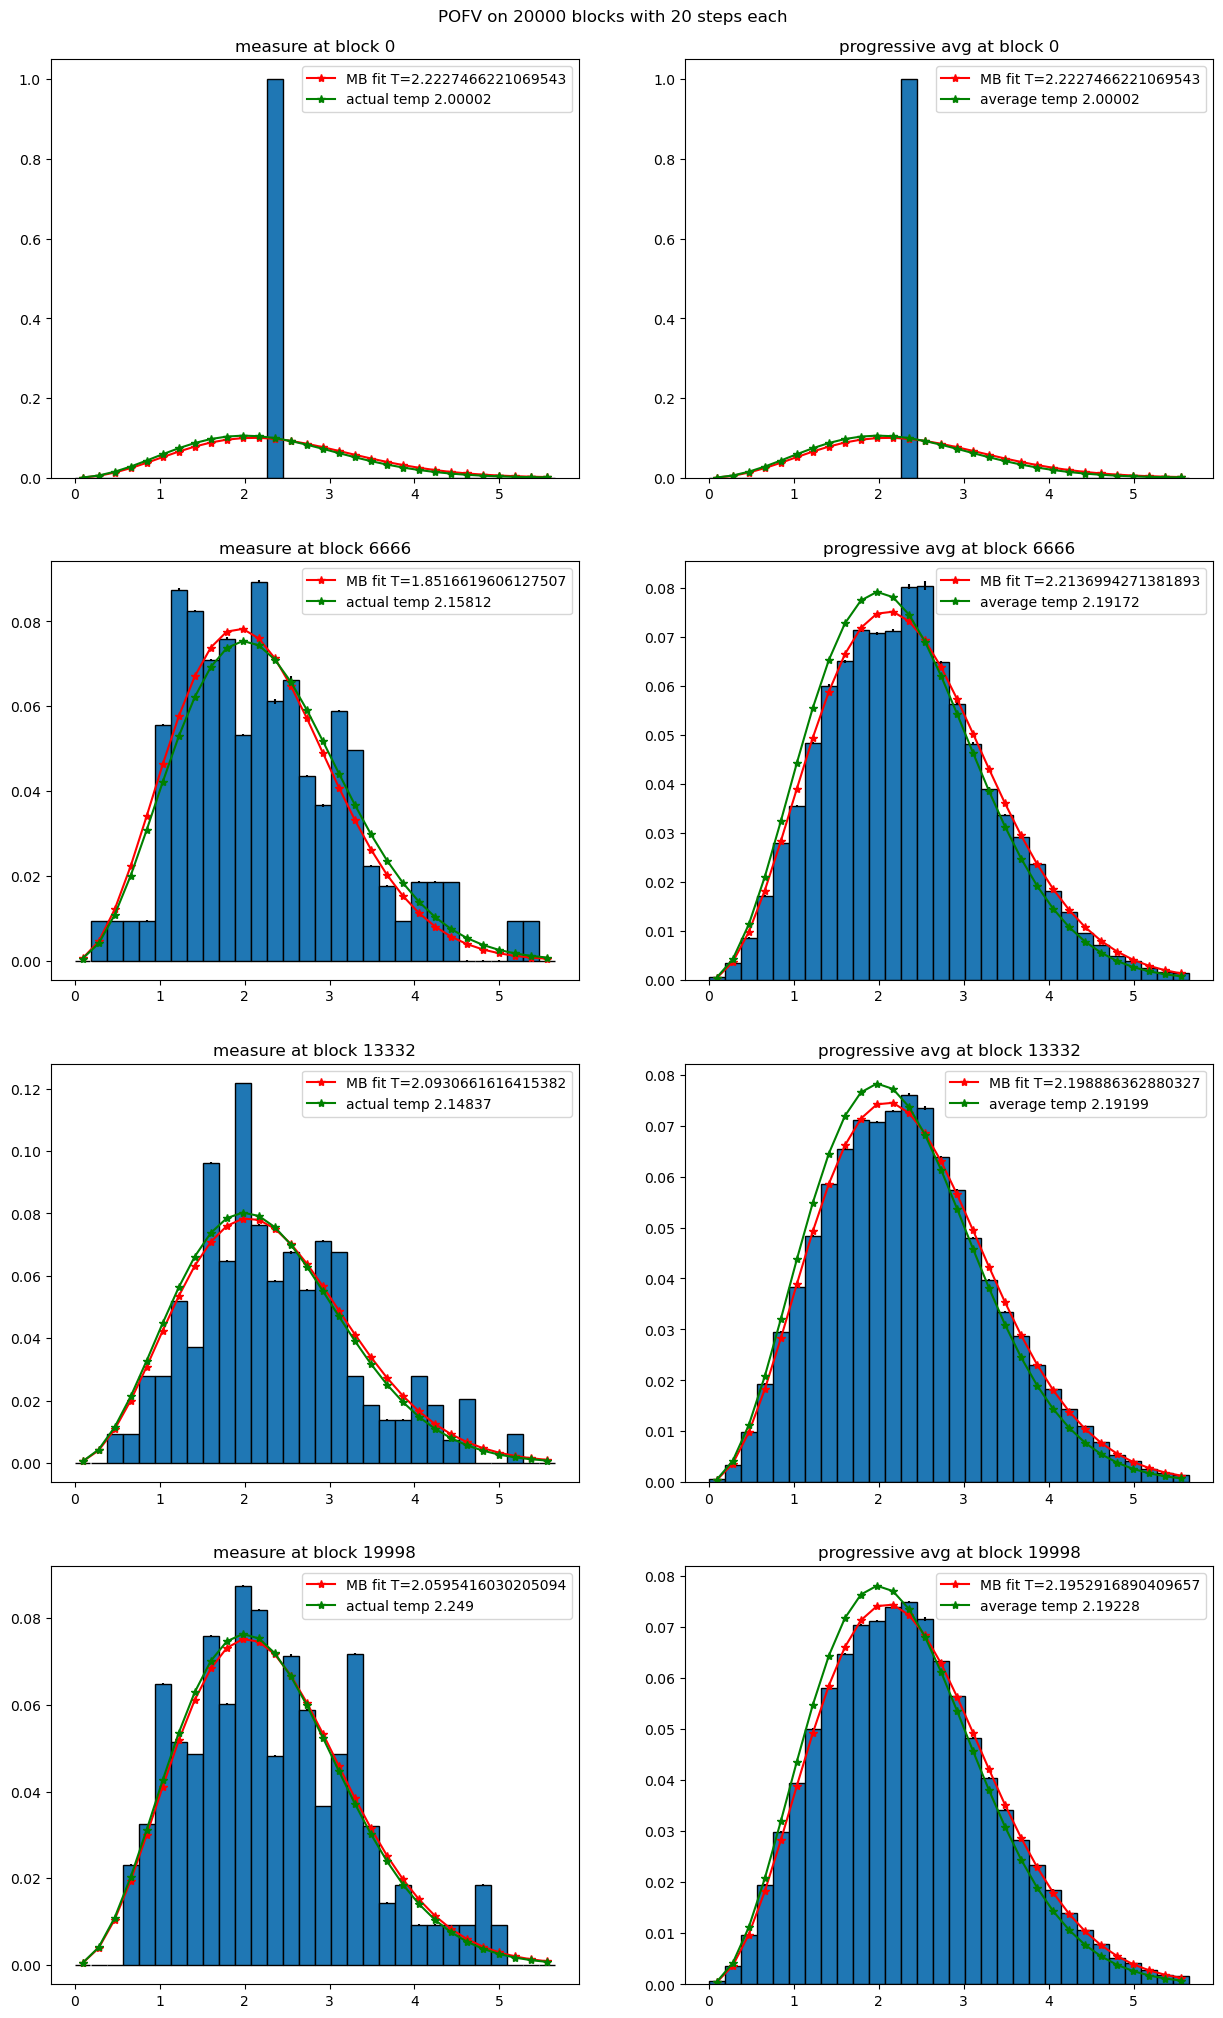

In [73]:
fig, ax=plt.subplots(nrows=4, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 20000 blocks with 20 steps each', y=0.9)

step=df.block.max()//3
for k in range(4):
    #select k block pofv data 
    dfb=df.loc[df['block']==step*k].reset_index(drop=True)

    ax[k,  0].set_title(f'measure at block {step*k}')
    
    # actual data
    ax[k,  0].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    # fit 
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], delta_fit['T_block'][step*k] ,delta_fit['C_block'][step*k])
        , marker='*', c='r', label=f'MB fit T={delta_fit['T_block'][step*k]}')
    
    ax[k, 0].plot(
        dfb['#vel'], MB(dfb['#vel'], T_d['ACTUAL_T:'][k], delta_fit['C_block'][step*k])
        , marker='*', c='g', label=f'actual temp {T_d['ACTUAL_T:'][step*k]}')
    
    ax[k, 0].legend()#loc='lower center')

    # prog avg
    ax[k,  1].set_title(f'progressive avg at block {step*k}')
    # actual data
    ax[k,  1].bar(
        dfb['#vel'], dfb['prog_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    # fit 
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], delta_fit['T_ave'][step*k],delta_fit['C_ave'][step*k])
        , marker='*', c='r', label=f'MB fit T={delta_fit['T_ave'][step*k]}')
    ax[k, 1].plot(
        dfb['#vel'], MB(dfb['#vel'], T_d['T_AVE:'][k], delta_fit['C_ave'][step*k])
        , marker='*', c='g', label=f'average temp {T_d['T_AVE:'][step*k]}')
    
    ax[k, 1].legend()#loc='lower center')


plt.show()

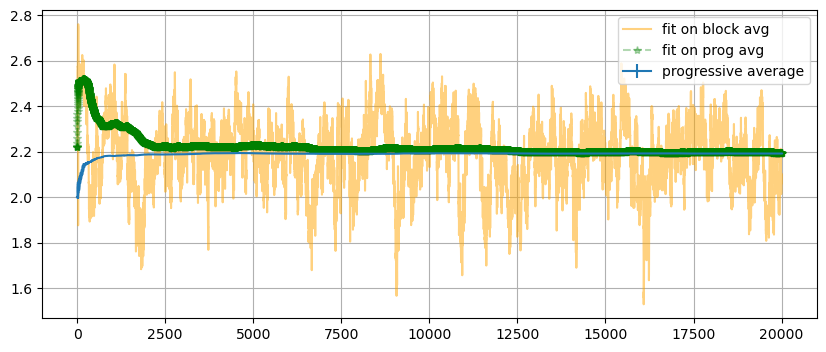

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(delta_fit['T_block'],'-',color='orange', alpha=0.5,  label='fit on block avg')
plt.plot(delta_fit['T_ave'],'--*', color='g', alpha=0.3, label='fit on prog avg')
plt.errorbar(T_d['#BLOCK:'], T_d['T_AVE:'], yerr=T_d['ERROR:'],  label='progressive average')
plt.grid()
plt.legend()
plt.show()

### Properties

In [75]:
K_d=pd.read_csv('OUTPUT/distrib/delta/kinetic_energy.dat', delimiter=r"\s+")

In [76]:
U_d=pd.read_csv('OUTPUT/distrib/delta/potential_energy.dat', delimiter=r"\s+")

In [77]:
P_d=pd.read_csv('OUTPUT/distrib/delta/pressure.dat', delimiter=r"\s+")

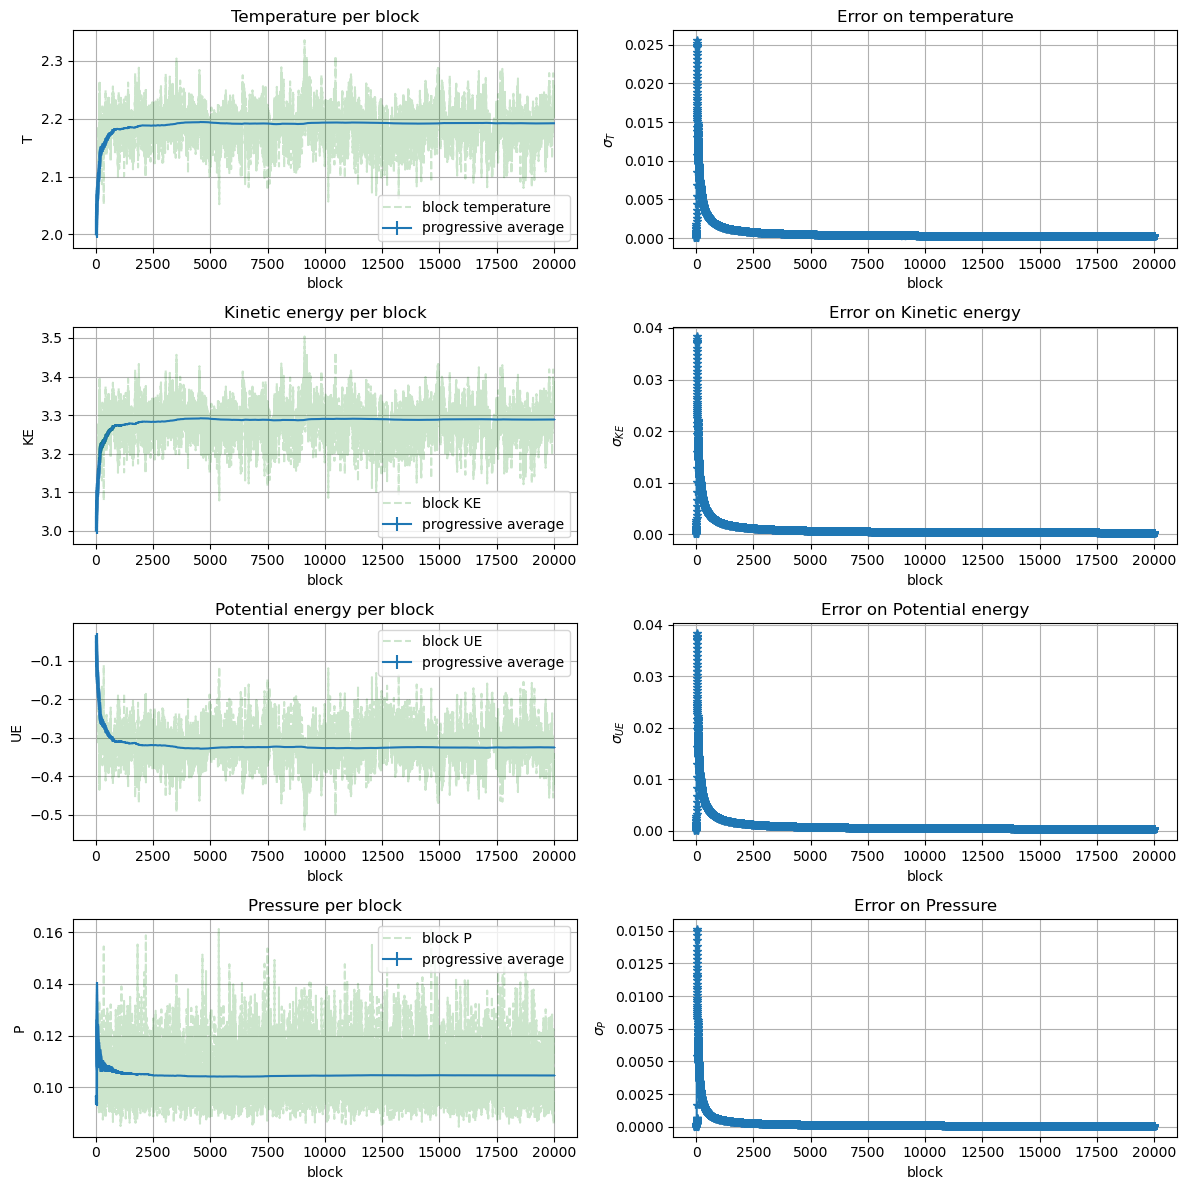

In [83]:
fig, ax = plt.subplots(4,2,  figsize=(12, 12))

ax[0, 0].set_title('Temperature per block')
# block averages
ax[0, 0].plot(
    T_d['#BLOCK:'][100:], T_d['ACTUAL_T:'][100:], #sliced for better visualization
    '--',color='g', alpha=0.2, label='block temperature'
) 

# progressive averages
ax[0, 0].errorbar(T_d['#BLOCK:'], T_d['T_AVE:'], yerr=T_d['ERROR:'],  label='progressive average')
ax[0, 0].set_ylabel('T')

ax[0,1].set_title('Error on temperature')
ax[0,1].plot(T_d['#BLOCK:'], T_d['ERROR:'], '-*')
ax[0,1].set_ylabel(r'$\sigma_T$')


ax[1,0].set_title('Kinetic energy per block')
# progressive averages
ax[1,0].errorbar(K_d['#BLOCK:'], K_d['KE_AVE:'], yerr=K_d['ERROR:'], label='progressive average')
# block averages
ax[1,0].plot(K_d['#BLOCK:'][100:], K_d['ACTUAL_KE:'][100:], '--',color='g', alpha=0.2, label='block KE')
ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Error on Kinetic energy')
ax[1,1].plot(K_d['#BLOCK:'], K_d['ERROR:'], '-*')
ax[1,1].set_ylabel(r'$\sigma_{KE}$')


ax[2,0].set_title('Potential energy per block')
ax[2,0].plot(U_d['#BLOCK:'][100:], U_d['ACTUAL_PE:'][100:], ls='--', color='g', alpha=0.2, label='block UE')
ax[2,0].errorbar(U_d['#BLOCK:'], U_d['PE_AVE:'], yerr=U_d['ERROR:'], label='progressive average')
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Error on Potential energy')
ax[2,1].plot(U_d['#BLOCK:'], U_d['ERROR:'], '-*')
ax[2,1].set_ylabel(r'$\sigma_{UE}$')


ax[3,0].set_title('Pressure per block')
ax[3,0].plot(P_d['#BLOCK:'][100:], P_d['ACTUAL_P:'][100:], ls='--', color='g', alpha=0.2,label='block P')
ax[3,0].errorbar(P_d['#BLOCK:'], P_d['P_AVE:'], yerr=P_d['ERROR:'], label='progressive average')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Error on Pressure')
ax[3,1].plot(P_d['#BLOCK:'], P_d['ERROR:'], '-*')
ax[3,1].set_ylabel(r'$\sigma_{P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')
    ax[k, 0].legend()

fig.tight_layout()

plt.show()

capire o eliminare, mi sa eliminare

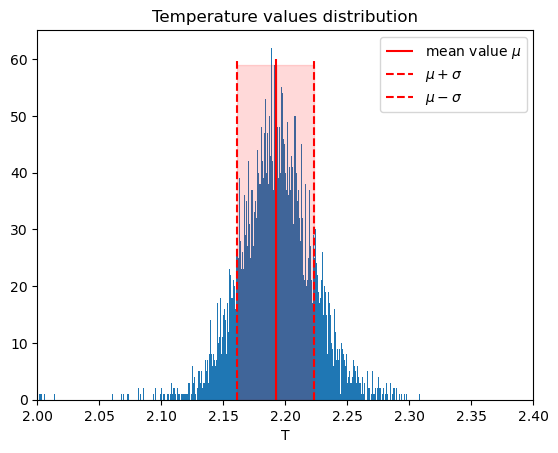

In [139]:
plt.title('Temperature values distribution')
plt.hist(T_d['ACTUAL_T:'], bins=5000)
plt.vlines(T_d['T_AVE:'][len(T_d)-1], ymin=0, ymax=60,  color='r', label=r'mean value $\mu$')
plt.vlines(
    T_d['T_AVE:'][len(T_d)-1]+np.sqrt(20000)*T_d['ERROR:'][len(T_d)-1],
    ymin=0, ymax=60, ls='--',  color='r', label=r'$\mu+\sigma$'
)

plt.vlines(
    T_d['T_AVE:'][len(T_d)-1]-np.sqrt(20000)*T_d['ERROR:'][len(T_d)-1],
    ymin=0, ymax=60, ls='--',  color='r', label=r'$\mu-\sigma$'
)

plt.fill_betweenx(
    [k for k in range(60)], T_d['T_AVE:'][len(T_d)-1], 
    T_d['T_AVE:'][len(T_d)-1]+np.sqrt(20000)*T_d['ERROR:'][len(T_d)-1], 
    color='r', alpha=0.15
)
plt.fill_betweenx(
    [k for k in range(60)], T_d['T_AVE:'][len(T_d)-1], 
    T_d['T_AVE:'][len(T_d)-1]-np.sqrt(20000)*T_d['ERROR:'][len(T_d)-1], 
    color='r', alpha=0.15
)

plt.xlabel('T')

plt.xlim([2.0, 2.4])
plt.legend()
#plt.grid()
plt.show()

In [25]:
histos=pd.DataFrame(columns=['vel']+[f'block_{k}' for k in range(400)])
histos['vel']=df.loc[df['block']==0]['#vel'].values
for k in range(400):
    histos[f'block_{k}']=df.loc[df.block==k]['block_avg'].values 
    


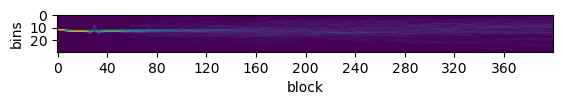

In [325]:
fig,ax = plt.subplots()
fig.set_figheight(10)
ax.imshow(histos[[f'block_{k}' for k in range(400)]])
plt.xlabel('block')#, size=150)
plt.ylabel('bins')#, size=150)
plt.xticks(range(0,  400, 40))#, size=100)
plt.yticks(range(0,  30, 10))#, size=100)

plt.savefig('images/delta_hist.png')

plt.show()

## Esercizio 04.3 [back to the future]

da sistemare bene

In [3]:
# POFV data
df_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/pofv.dat', header=None, names=['#vel', 'block_avg', 'prog_av', 'err'], skiprows=1,
               sep=r"\s+")
df_btf['block']=0
df_btf['block']=df_btf.index//30

# Temperature data
T_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/temperature.dat', skiprows=1, delimiter=r'\s+',names=['block','actual_T','T_ave','error'])



/tmp/ipykernel_276583/2678452637.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[k//2,  k%2].legend(loc='lower center')


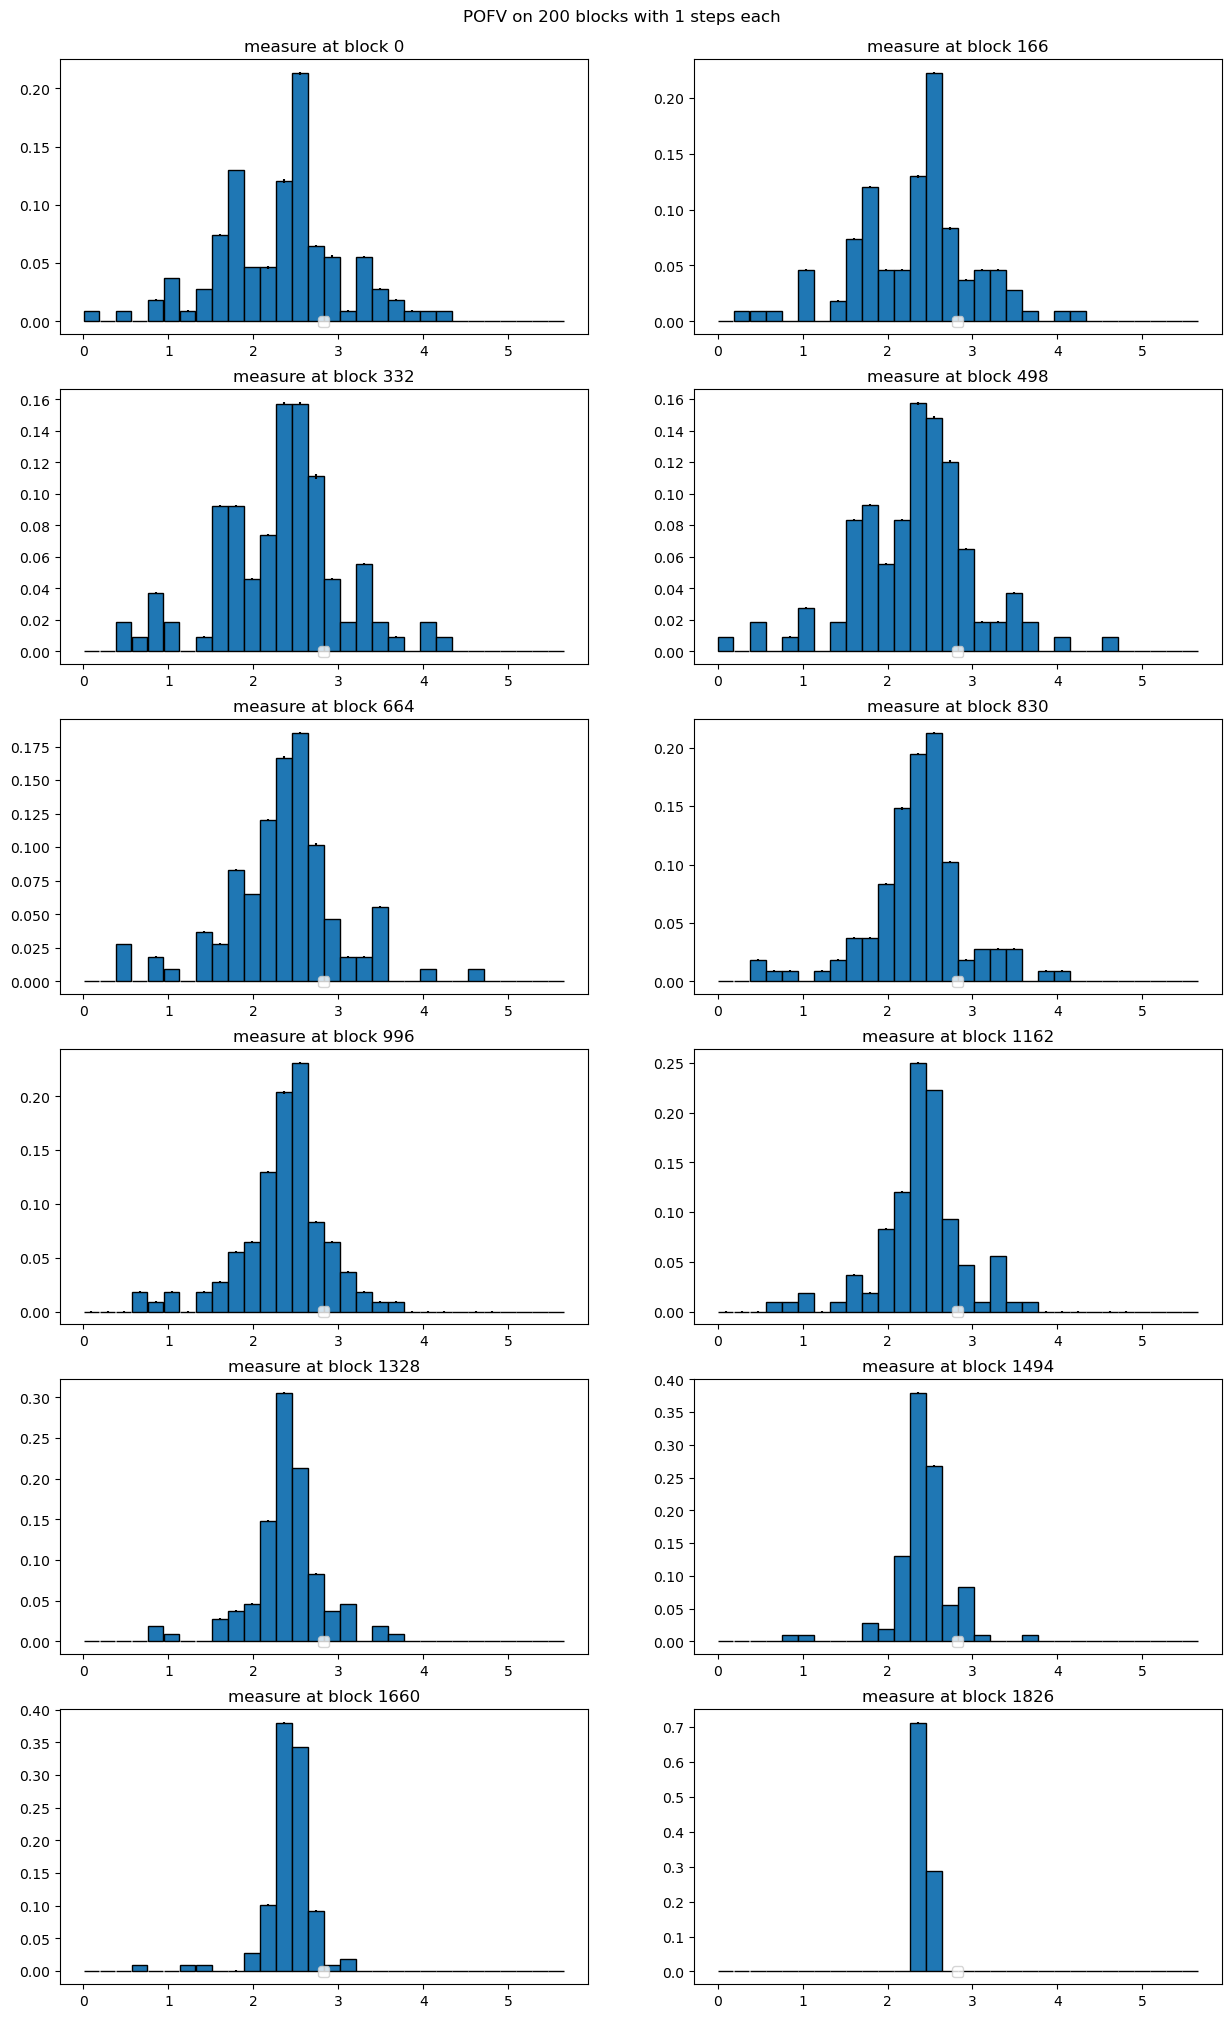

In [5]:
fig, ax=plt.subplots(nrows=6, ncols=2)
fig.set_figwidth(15)
fig.set_figheight(25)

fig.suptitle('POFV on 200 blocks with 1 steps each', y=0.9)

step=df_btf.block.max()//12
for k in range(12):
    #select k block pofv data 
    dfb=df_btf.loc[df_btf['block']==step*(k+1)].reset_index(drop=True)

    ax[k//2,  k%2].set_title(f'measure at block {step*k}')
    
    # actual data
    ax[k//2,  k%2].bar(
        dfb['#vel'], dfb['block_avg'], 
        yerr=dfb['err'], 
        width=dfb['#vel'].max()/30, edgecolor='black')
    
    ax[k//2,  k%2].legend(loc='lower center')

plt.show()

In [6]:
last=df_btf.loc[df_btf['block']==df_btf['block'].max()].reset_index(drop=True)
last

,#vel,block_avg,prog_av,err,block
0,0.094281,0.000000,0.001514,0.000077,1999
1,0.282843,0.000000,0.001162,0.000069,1999
2,0.471405,0.000000,0.009292,0.000212,1999
3,0.659966,0.000000,0.005708,0.000133,1999
4,0.848528,0.000000,0.011236,0.000177,1999
5,1.037090,0.000000,0.016069,0.000256,1999
6,1.225650,0.000000,0.005005,0.000139,1999
7,1.414210,0.000000,0.015602,0.000291,1999
8,1.602780,0.000000,0.040657,0.000675,1999
9,1.791340,0.000000,0.066398,0.001030,1999


<BarContainer object of 30 artists>

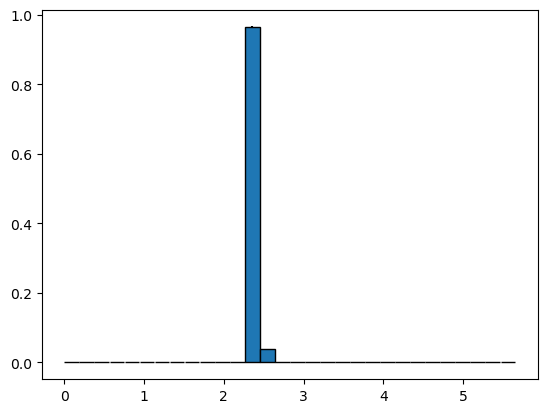

In [7]:
plt.bar(
        last['#vel'], last['block_avg'], 
        yerr=last['err'], 
        width=last['#vel'].max()/30, edgecolor='black')

### Properties

In [8]:
K_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/kinetic_energy.dat', delimiter=r"\s+")

In [9]:
U_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/potential_energy.dat', delimiter=r"\s+")

In [10]:
P_btf=pd.read_csv('OUTPUT/bckwd/200bl/bw/pressure.dat', delimiter=r"\s+")

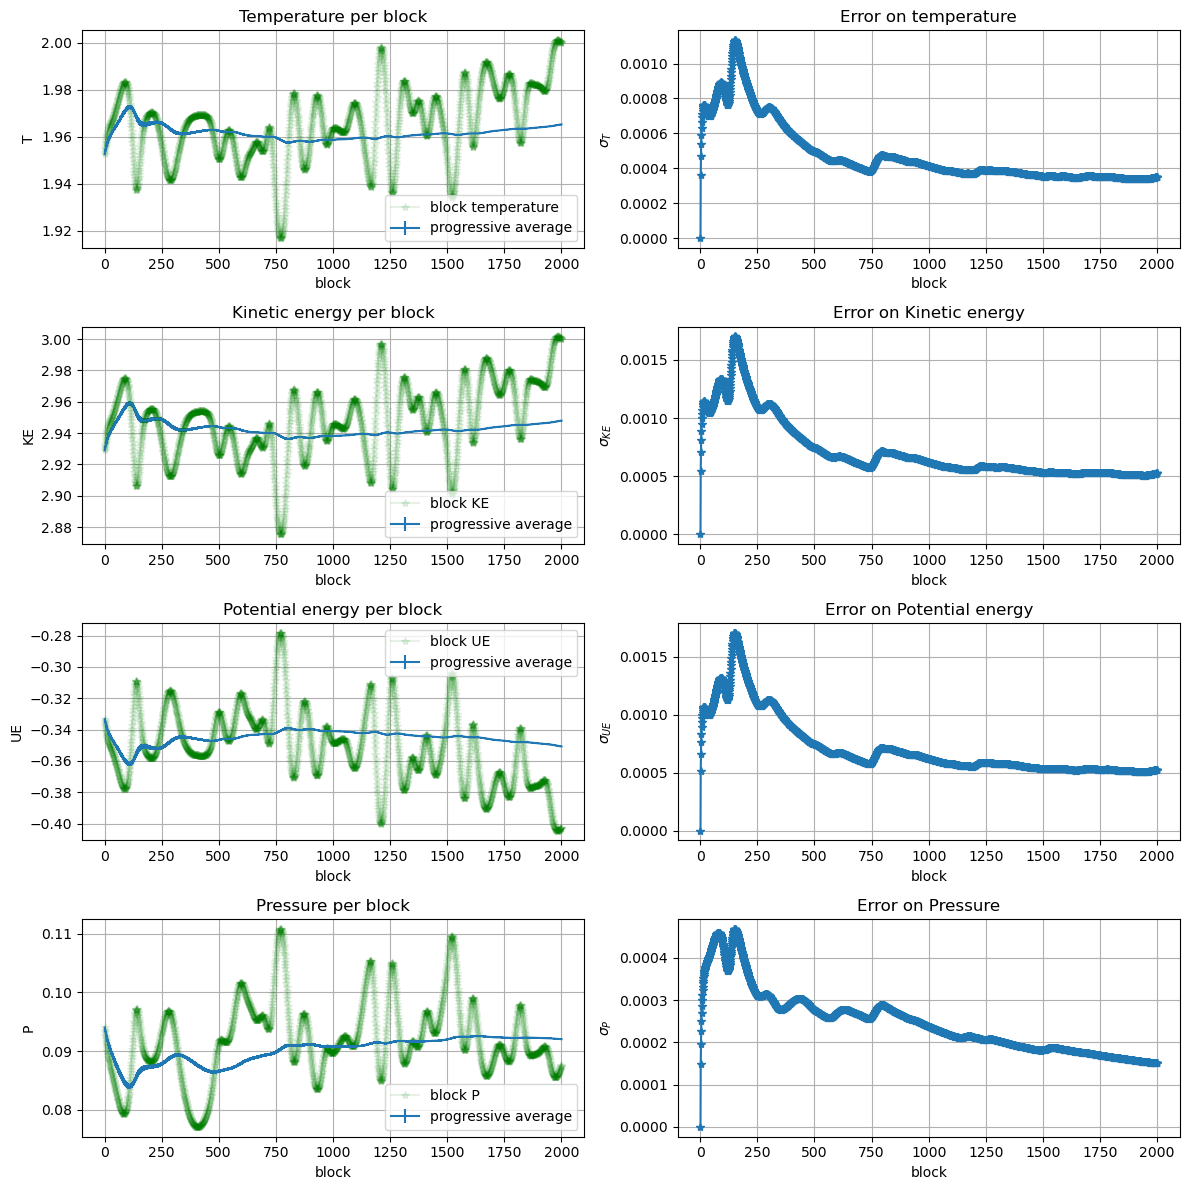

In [11]:
fig, ax = plt.subplots(4,2,  figsize=(12, 12))
ax[0, 0].set_title('Temperature per block')

# block averages
ax[0, 0].plot(T_btf['block'], T_btf['actual_T'], '-*',color='g', alpha=0.1, label='block temperature') #sliced for better visualization

# fit from MB
#ax[0, 0].plot(T.block, fit_temp_ba, '--o', color='orange', label='block pofv-fitted temperature')
#ax[0, 0].plot(T.block, fit_temp_pa, '--*', color='red', label='progressive pofv-fitted temperature')

# progressive averages
ax[0, 0].errorbar(T_btf['block'], T_btf['T_ave'], yerr=T_btf['error'],  label='progressive average')

ax[0, 0].set_ylabel('T')

ax[0,1].set_title('Error on temperature')

ax[0,1].plot(T_btf['block'], T_btf['error'], '-*')

ax[0,1].set_ylabel(r'$\sigma_T$')


ax[1,0].set_title('Kinetic energy per block')
# progressive averages
ax[1,0].errorbar(K_btf['#BLOCK:'], K_btf['KE_AVE:'], yerr=K_btf['ERROR:'], label='progressive average')
# block averages
ax[1,0].plot(K_btf['#BLOCK:'], K_btf['ACTUAL_KE:'], '-*',color='g', alpha=0.1, label='block KE')
#ax[1,0].scatter(K_d['#BLOCK:'], K_d['ACTUAL_KE:'], marker='*',color='g',alpha=0.3, label='block KE')

ax[1,0].set_ylabel('KE')


ax[1,1].set_title('Error on Kinetic energy')
ax[1,1].plot(K_btf['#BLOCK:'], K_btf['ERROR:'], '-*')
ax[1,1].set_ylabel(r'$\sigma_{KE}$')


ax[2,0].set_title('Potential energy per block')
ax[2,0].plot(U_btf['#BLOCK:'], U_btf['ACTUAL_PE:'], '-*', color='g', alpha=0.1, label='block UE')
#ax[2,0].scatter(U_d['#BLOCK:'], U_d['ACTUAL_PE:'], marker='*',color='g', alpha=0.3, label='block UE')
ax[2,0].errorbar(U_btf['#BLOCK:'], U_btf['PE_AVE:'], yerr=U_btf['ERROR:'], label='progressive average')
#ax[0].set_xticks(range(0, T.block.max(), 15))#, rotation=45)
ax[2,0].set_ylabel('UE')

ax[2,1].set_title('Error on Potential energy')
ax[2,1].plot(U_btf['#BLOCK:'], U_btf['ERROR:'], '-*')
ax[2,1].set_ylabel(r'$\sigma_{UE}$')


ax[3,0].set_title('Pressure per block')
ax[3,0].plot(P_btf['#BLOCK:'], P_btf['ACTUAL_P:'], '-*', color='g', alpha=0.1,label='block P')
#ax[3,0].scatter(P_d['#BLOCK:'], P_d['ACTUAL_P:'], marker='*',color='g', alpha=0.3,label='block P')
ax[3,0].errorbar(P_btf['#BLOCK:'], P_btf['P_AVE:'], yerr=P_btf['ERROR:'], label='progressive average')
ax[3,0].set_ylabel('P')

ax[3,1].set_title('Error on Pressure')
ax[3,1].plot(P_btf['#BLOCK:'], P_btf['ERROR:'], '-*')
ax[3,1].set_ylabel(r'$\sigma_{P}$')

for k in range(4):
    for j in range(2):
        ax[k,j].grid()
        ax[k, j].set_xlabel('block')
    ax[k, 0].legend()

fig.tight_layout()

plt.show()